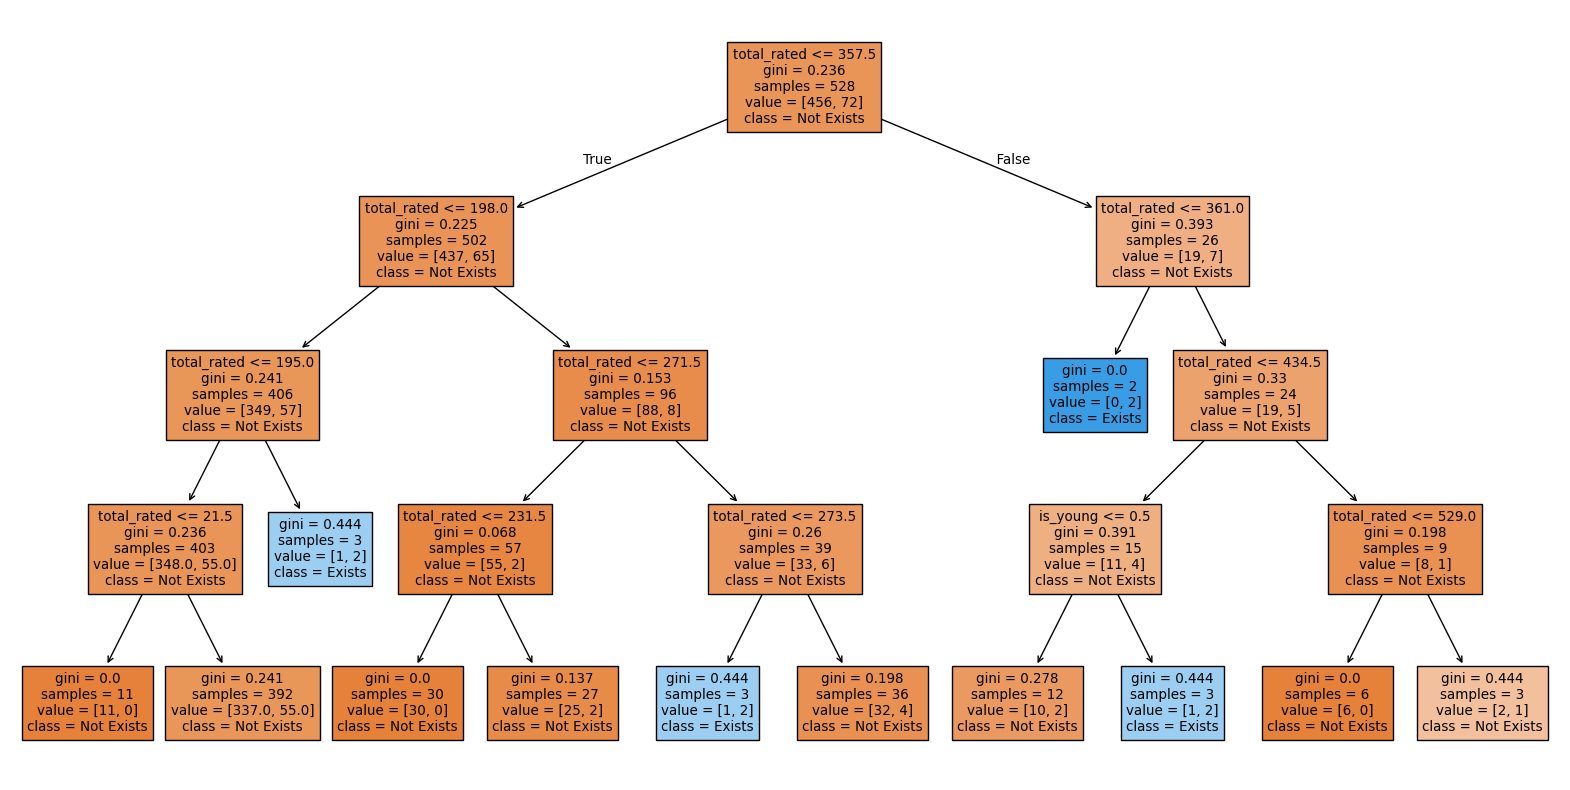

Accuracy: 0.8195488721804511
              precision    recall  f1-score   support

           0       0.83      0.98      0.90       111
           1       0.00      0.00      0.00        22

    accuracy                           0.82       133
   macro avg       0.42      0.49      0.45       133
weighted avg       0.69      0.82      0.75       133

total_rated: 0.8837
is_young: 0.1163
gender: 0.0000


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# Step 1: Load the dataset
df = pd.read_csv("user_genre_rating_summary.csv")

# Step 2: Encode target variable
df['exists_in_merged_user_data'] = df['exists_in_merged_user_data'].astype(int)  # Convert TRUE/FALSE to 1/0

occupation_map = {
    0: "administrator",
    1: "artist",
    2: "doctor",
    3: "educator",
    4: "engineer",
    5: "entertainment",
    6: "executive",
    7: "healthcare",
    8: "homemaker",
    9: "lawyer",
    10: "librarian",
    11: "marketing",
    12: "none",
    13: "other",
    14: "programmer",
    15: "retired",
    16: "salesman",
    17: "scientist",
    18: "student",
    19: "technician",
    20: "writer"
}
df['occupation'] = df['occupation'].map(occupation_map)

df['is_young'] = df['age'].apply(lambda x: 1 if x < 25 else 0)

df['files_flag'] = df['files_present_in'].apply(lambda x: 1 if x > 4 else 0)


genre_columns = [
    'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime',
    'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 
    'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]

useless_columns = [
    'occupation_educator',
    'occupation_technician',
    'occupation_student',
    'occupation_scientist',
    'occupation_salesman',
    'occupation_retired',
    'occupation_none',
    'occupation_marketing',
    'occupation_lawyer',
    'occupation_homemaker',
    'occupation_engineer',
    'occupation_doctor'
]


# Step 3: Define features and target
X = df.drop(columns=['user_id', 'exists_in_merged_user_data', 'files_present_in','zip_code','age','files_flag','occupation'] +genre_columns) # drop ID and target
#X = pd.get_dummies(X, columns=['occupation'])
#X = X.drop(columns=useless_columns)
y = df['files_flag']

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Step 5: Train Decision Tree

clf = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    min_samples_leaf=2
)



clf.fit(X_train, y_train)

# Step 6: Evaluate


# Step 7: Plot the tree
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=X.columns, class_names=["Not Exists", "Exists"], filled=True)
plt.savefig("decision_tree_plot.png", dpi=300, bbox_inches='tight')
plt.show()

y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


importances = clf.feature_importances_
features = X.columns
for i in sorted(zip(importances, features), reverse=True):
    print(f"{i[1]}: {i[0]:.4f}")